In [2]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
# get utils for thresholds
from src import util_analysis 

## Load model data and meta files

In [3]:
room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/eval/manifest_room.pdpkl')
# for tuple_ in room_manifest.itertuples():
#     print(tuple_)
#     break
room_material_map = {}
for row in room_manifest.itertuples():
    wall1 = row.material_x0[0].split(',')[0]
    wall2 = row.material_y1[0].split(',')[0]
    if wall1 == wall2:
        wall_str = f"{wall1} walls"
    else:
        wall_str = f"{wall1} and {wall2} walls"

    floor = row.material_z0[0].split(',')[0]
    ceiling = row.material_z1[0].split(',')[0]
    name_str = f"{wall_str} \n {floor} floor \n {ceiling} ceiling"

    if row.index_room in [5, 6]:
        name_str = 'Alternate speaker room'
    if row.index_room in [6, 8]:
        name_str += ' \n head rotated'
    else:
        head_rotated = ''
    if 'Anechoic' in name_str:
        name_str = "Anechoic"
    room_material_map[row.index_room] = name_str
# room_material_map = {row.index_room: f"{row.material_x0[0].split(',')[0]} and \n {row.material_y1[0].split(',')[0]} walls \n {row.material_z0[0].split(',')[0]} floor \n {row.material_z1[0].split(',')[0]} ceiling" for row in room_manifest.itertuples()}
# room_material_map[5] = 'standard speaker room'
room_material_map

{0: 'Anechoic',
 1: 'Wood panelling on glass fiber blanket walls \n Carpet on foam rubber padding floor \n Highly absorptive panels ceiling',
 2: 'Brick walls \n Wood parquet on concrete floor \n Plaster ceiling',
 3: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 4: 'Concrete walls \n Linoleum floor \n Acoustic tiles ceiling',
 5: 'Alternate speaker room',
 6: 'Alternate speaker room \n head rotated',
 7: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 8: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling \n head rotated'}

In [4]:
import pickle 

# manifest_path = "binaural_test_manifests/sim_2024_human_experiment.pkl"
manifest_path = "binaural_test_manifests/symmetric_distractor_conditions_w_front_back_neg_21_to_6_dBSNR_min_reverb_mit_room.pkl"
with open(manifest_path, "rb") as f: 
    manifest = pickle.load(f)
    

In [5]:
manifest_df  = pd.DataFrame(manifest.values())
manifest_df

,target_loc,distract_loc,snr,symmetric_distractor,test_room_meta
0,"(0, -20)","[0, -20]",6.0,True,{'room_manifest': '/om2/user/imgriff/spatial_a...
1,"(0, -20)","[0, -20]",3.0,True,{'room_manifest': '/om2/user/imgriff/spatial_a...
2,"(0, -20)","[0, -20]",0.0,True,{'room_manifest': '/om2/user/imgriff/spatial_a...
3,"(0, -20)","[0, -20]",-3.0,True,{'room_manifest': '/om2/user/imgriff/spatial_a...
4,"(0, -20)","[0, -20]",-6.0,True,{'room_manifest': '/om2/user/imgriff/spatial_a...
...,...,...,...,...,...
415,"(0, 40)","[0, 0]",-9.0,False,{'room_manifest': '/om2/user/imgriff/spatial_a...
416,"(0, 40)","[0, 0]",-12.0,False,{'room_manifest': '/om2/user/imgriff/spatial_a...
417,"(0, 40)","[0, 0]",-15.0,False,{'room_manifest': '/om2/user/imgriff/spatial_a...
418,"(0, 40)","[0, 0]",-18.0,False,{'room_manifest': '/om2/user/imgriff/spatial_a...


In [6]:
# spkr_room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/mit_bldg46room1004/manifest_room.pdpkl')
spkr_room_manifest = pd.read_pickle('/om2/user/imgriff/spatial_audio_pipeline/assets/brir/mit_bldg46room1004_min_reverb/manifest_room.pdpkl')

In [7]:

spkr_room_manifest

,head_azim,head_pos_xyz,index_room,is_outdoor,material_x0,material_x1,material_y0,material_y1,material_z0,material_z1,room_dim_xyz,room_materials
0,0,"[2.3, 3.6, 0.9]",0,False,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,carpet on foam rubber padding,"highly absorptive panels, 1in, 16in below ceiling","[4.66, 5.9, 2.48]","[11, 11, 11, 11, 15, 20]"
1,0,"[3.6, 2.36, 0.9]",1,False,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,carpet on foam rubber padding,"highly absorptive panels, 1in, 16in below ceiling","[5.9, 4.66, 2.48]","[11, 11, 11, 11, 15, 20]"
2,0,"[2.36, 2.3, 0.9]",2,False,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,carpet on foam rubber padding,"highly absorptive panels, 1in, 16in below ceiling","[4.66, 5.9, 2.48]","[11, 11, 11, 11, 15, 20]"
3,0,"[2.3, 2.3, 0.9]",3,False,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,wood panelling on glass fiber blanket,carpet on foam rubber padding,"highly absorptive panels, 1in, 16in below ceiling","[5.9, 4.66, 2.48]","[11, 11, 11, 11, 15, 20]"


In [8]:
# Path to results 

output_paths = list(Path(f"binaural_eval/texture_srm_experiment/").glob("*/*.pkl"))

# stim_manifest_df = pd.read_pickle('/om/user/imgriff/datasets/speech_in_synthetic_textures/separated_sources/manifest.pdpkl')
texture_manifest  = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/human_experiment_v00/synthetic_textures/manifest.pdpkl')
texture_ix_map = {item.index_texture:item.label for item in texture_manifest[['index_texture', 'label']].drop_duplicates().itertuples()}
# remove '_yout' from labels 
texture_ix_map = {k:re.sub('_yout$', '', v) for k,v in texture_ix_map.items()}

word_class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
ix_to_word = {v:k for k,v in word_class_map.items()}
# stim_manifest_df['target_word'] = stim_manifest_df['label_word_int'].map(ix_to_word)

remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 

results_dfs = []

gend_map = {True:'same', False:'different'}

for path in output_paths:
    if not any(name in str(path) for name in ['word_task_half_co_loc_v08_gender_bal_4M_sanity']):# 'word_task_half_co_loc_v08']):
        continue
    if 'modulated' in path.stem:
        continue 
    res_dict = pickle.load(open(path, 'rb'))
    df = pd.DataFrame.from_dict(res_dict)
    # break
    df.rename(columns={"results": "accuracy"}, inplace=True)
    df['model'] = path.parent.stem

    # if not 'min' in path.stem: 
    #     df = df.join(anech_stim_manifest_df[['word', 'bg_word','gender', 'bg_gender']], how='outer')
    #     df.rename(columns={'bg_word':"distractor_word"}, inplace=True)  
    #     df['sex_cond'] = df["gender"].values == df['bg_gender'].values
    #     df['sex_cond'] =  df['sex_cond'].map(gend_map)
    # else:
    # # # merge with stim manifest
    # df.loc[df.index.values, ['word', 'distractor_word','sex_cond']] = stim_manifest_df.loc[df.stim_ix_list.values, ['word', 'distractor_word','sex_cond']].values
    df['target_word'] = df['true_word_int'].map(ix_to_word)
    df['pred_word'] = df['preds'].map(ix_to_word)
    df['correct'] = (df['true_word_int'] == df['preds']).astype('int')
    # df['str_confusions'] = df[['pred_word', 'distractor_word']].apply(lambda x: 1 if x.pred_word in x.distractor_word else 0, axis=1)
    if 'clean' in path.stem:
        snr = 'clean'
    else:
        snr = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
    df['snr'] = snr 
    df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
    df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')[:2]
    # # map azim to 0-180
    df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
    df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
    df['target_elev'] = df['target_elev'].astype(int)
    df['distractor_elev'] = df['distractor_elev'].astype(int)
    df['room_ix'] = int(re.search('room(-?\d+)', path.stem).group(0).strip('room'))
    df['room_type'] = re.search('distractor_(.*?)_room', path.stem).group(0).split('distractor_')[-1].split("_room")[0]
    df['n_distractors'] = 1 if '1_distractor' in path.stem else 2
    df['test_set'] = 'all_stim' if 'all_stim' in path.stem else 'subset'
    df['texture_str'] = df['textures'].map(texture_ix_map)
    results_dfs.append(df)

results = pd.concat(results_dfs)

In [9]:
results.loc[results.room_type == 'eval', 'room_str'] = results.loc[results.room_type == 'eval', 'room_ix'].map(room_material_map)

results.loc[results.room_type == 'mitb46', 'room_str'] = 'Normal speaker array'
results.loc[results.room_type == 'mitb46', 'room_ix'] = 9 # use n from diff room notebook

results.loc[results.room_type.str.contains('reverb'), 'room_str'] = 'Min. reverb speaker array'
results.loc[results.room_type.str.contains('reverb'), 'room_ix'] = 10 # use n from diff room notebook

In [ ]:
# results[(results.target_azim == results.distractor_azim) & (results.target_elev != results.distractor_elev)]

In [12]:
grouped_model_results = results.groupby(['model', 'target_azim', 'target_elev', 'distractor_azim', 'texture_str',
                                   'distractor_elev','snr', 'room_str']).agg({'accuracy':['mean', 'sem']}).reset_index()
# flatten multiindex
grouped_model_results.columns = ['_'.join(col).strip() for col in grouped_model_results.columns.values]
# remove trailing underscore
grouped_model_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_model_results.columns.values]



In [13]:
grouped_model_results

,model,target_azim,target_elev,distractor_azim,texture_str,distractor_elev,snr,room_str,accuracy_mean,accuracy_sem
0,word_task_half_co_loc_v08_gender_bal_4M_sanity,0,-20,-180,16mm_projector,-20,-21,Min. reverb speaker array,0.003300,0.003300
1,word_task_half_co_loc_v08_gender_bal_4M_sanity,0,-20,-180,16mm_projector,-20,-18,Min. reverb speaker array,0.009901,0.005697
2,word_task_half_co_loc_v08_gender_bal_4M_sanity,0,-20,-180,16mm_projector,-20,-15,Min. reverb speaker array,0.062706,0.013951
3,word_task_half_co_loc_v08_gender_bal_4M_sanity,0,-20,-180,16mm_projector,-20,-12,Min. reverb speaker array,0.188119,0.022488
4,word_task_half_co_loc_v08_gender_bal_4M_sanity,0,-20,-180,16mm_projector,-20,-12,Normal speaker array,0.072607,0.014932
...,...,...,...,...,...,...,...,...,...,...
16249,word_task_half_co_loc_v08_gender_bal_4M_sanity,0,40,0,wind_through_grass,40,-3,Min. reverb speaker array,0.617162,0.027971
16250,word_task_half_co_loc_v08_gender_bal_4M_sanity,0,40,0,wind_through_grass,40,0,Min. reverb speaker array,0.696370,0.026460
16251,word_task_half_co_loc_v08_gender_bal_4M_sanity,0,40,0,wind_through_grass,40,3,Normal speaker array,0.650165,0.027444
16252,word_task_half_co_loc_v08_gender_bal_4M_sanity,0,40,0,wind_through_grass,40,6,Min. reverb speaker array,0.795380,0.023214


In [40]:
group

,model,room_str,distractor_azim,texture_str,snr,accuracy_mean
846,word_task_half_co_loc_v08_gender_bal_4M_sanity,Anechoic,60,disc_grinder,-21,0.303630
847,word_task_half_co_loc_v08_gender_bal_4M_sanity,Anechoic,60,disc_grinder,-18,0.429043
848,word_task_half_co_loc_v08_gender_bal_4M_sanity,Anechoic,60,disc_grinder,-15,0.534653
849,word_task_half_co_loc_v08_gender_bal_4M_sanity,Anechoic,60,disc_grinder,-12,0.603960
850,word_task_half_co_loc_v08_gender_bal_4M_sanity,Anechoic,60,disc_grinder,-3,0.795380
851,word_task_half_co_loc_v08_gender_bal_4M_sanity,Anechoic,60,disc_grinder,0,0.854785
852,word_task_half_co_loc_v08_gender_bal_4M_sanity,Anechoic,60,disc_grinder,3,0.841584
853,word_task_half_co_loc_v08_gender_bal_4M_sanity,Anechoic,60,disc_grinder,6,0.838284


,model,room_str,distractor_azim,texture_str,snr,accuracy_mean
473,word_task_half_co_loc_v08_gender_bal_4M_sanity,Anechoic,30,16mm_projector,-21,0.006601
474,word_task_half_co_loc_v08_gender_bal_4M_sanity,Anechoic,30,16mm_projector,-12,0.280528
475,word_task_half_co_loc_v08_gender_bal_4M_sanity,Anechoic,30,16mm_projector,-9,0.544554
476,word_task_half_co_loc_v08_gender_bal_4M_sanity,Anechoic,30,16mm_projector,-6,0.660066
477,word_task_half_co_loc_v08_gender_bal_4M_sanity,Anechoic,30,16mm_projector,0,0.768977
478,word_task_half_co_loc_v08_gender_bal_4M_sanity,Anechoic,30,16mm_projector,3,0.816832
479,word_task_half_co_loc_v08_gender_bal_4M_sanity,Anechoic,30,16mm_projector,6,0.844884


In [78]:
# avg threshold estimates for 0 and 10 azimuth separation 
to_plot = grouped_model_results[
                        #   & (grouped_model_results.room_str == 'Min. reverb speaker array')
                         (grouped_model_results.model == 'word_task_half_co_loc_v08_gender_bal_4M_sanity')
                         & (grouped_model_results.distractor_azim.isin([0, -10, -30, -60])) 
                        #   & (grouped_model_results.snr.isin([6,3, 0, -3, -6, -9,]))
                          ]

to_plot.distractor_azim = to_plot.distractor_azim.abs()                    
azim_results_for_thresh = to_plot.groupby(['model','room_str', 'distractor_azim', 'texture_str', 'snr']).agg({'accuracy_mean':'mean'}).reset_index()



azim_thresholds = []
# p0 = [0.0, -4, 4]
for (model, room, dist_type, azim), group in azim_results_for_thresh.groupby(['model', 'room_str', 'texture_str', 'distractor_azim']): #, 'gender_cond']):
    try:
        thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.accuracy_mean.values, bounds_from_data=True)#, p0=p0)
        if np.isnan(thresh):
            print(f"Threshold is nan for azim {azim}")
        azim_thresholds.append({'model': model, "room":room, "dist_type":dist_type, 'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
    except Exception as e:
        # print(e)
        # print(f"Error for azim {azim}, room {room}, dist_type {dist_type}")
        continue
    
azim_thresh_df = pd.DataFrame(azim_thresholds)

/tmp/ipykernel_712194/508394100.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot.distractor_azim = to_plot.distractor_azim.abs()


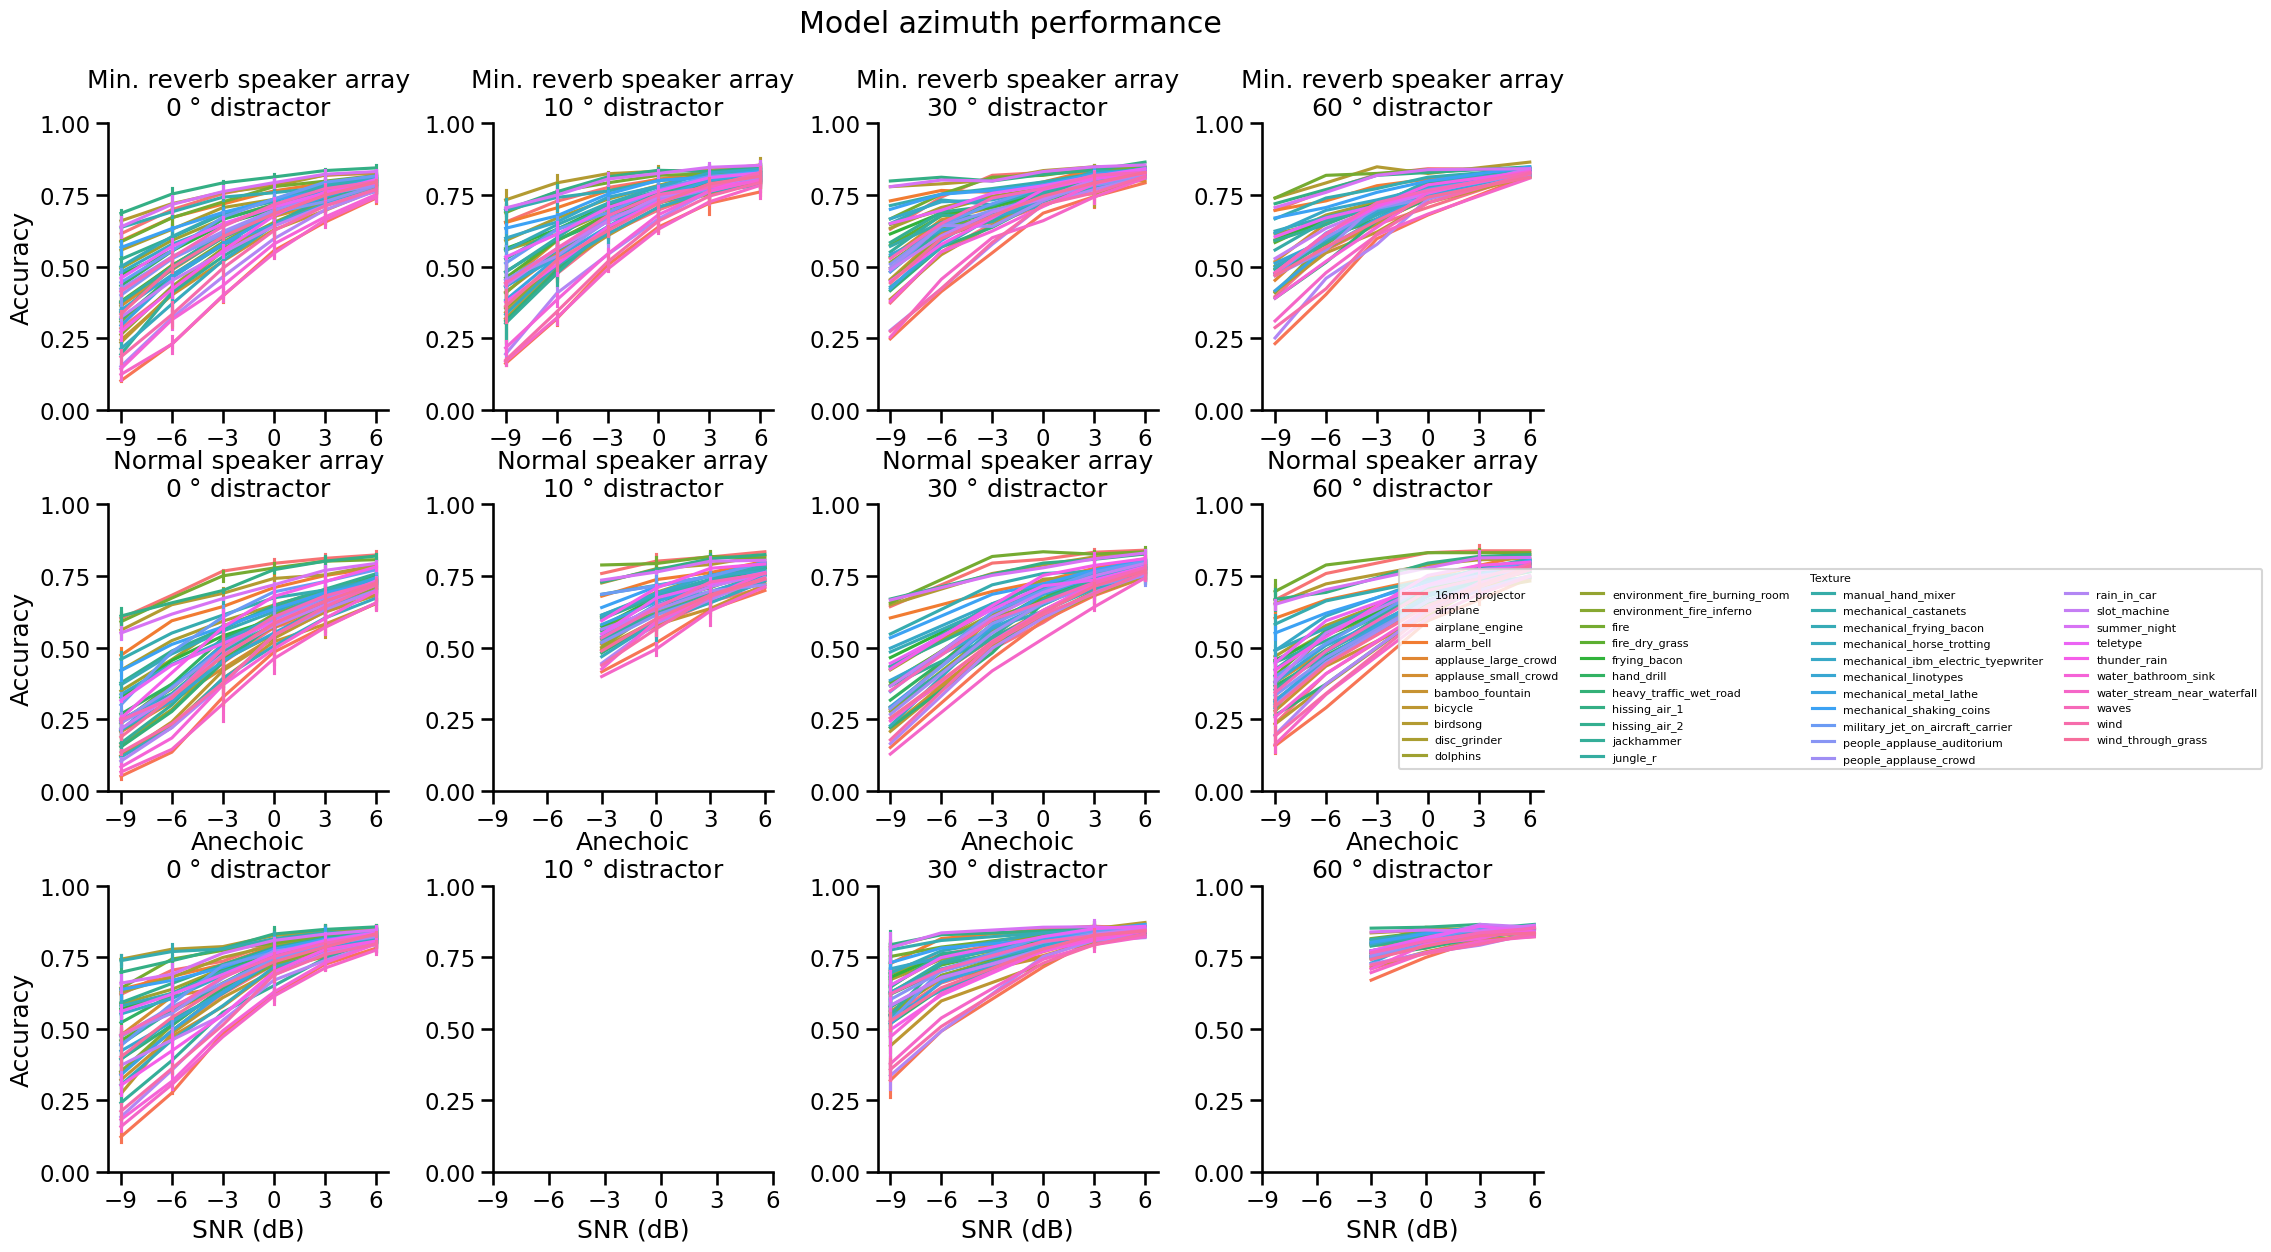

In [80]:
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                x='snr', y='accuracy_mean', col="distractor_azim",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                hue='texture_str', 
                row='room_str',
                # palette=palette, 
                errorbar=('se', 2),
                err_style='bars',
                height=4, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
# new_title = 'Distractor\nazimuth\n($\degree$, +/-)'
# g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{row_name}\n{col_name}$\degree$ distractor")
plt.suptitle(f'Model azimuth performance', y=1.05)
# make legend have columns 
g._legend.remove()
g.fig.legend( title='Texture', loc='center right', fontsize=8, title_fontsize=8, ncol=4, bbox_to_anchor=(1.1, 0.5))


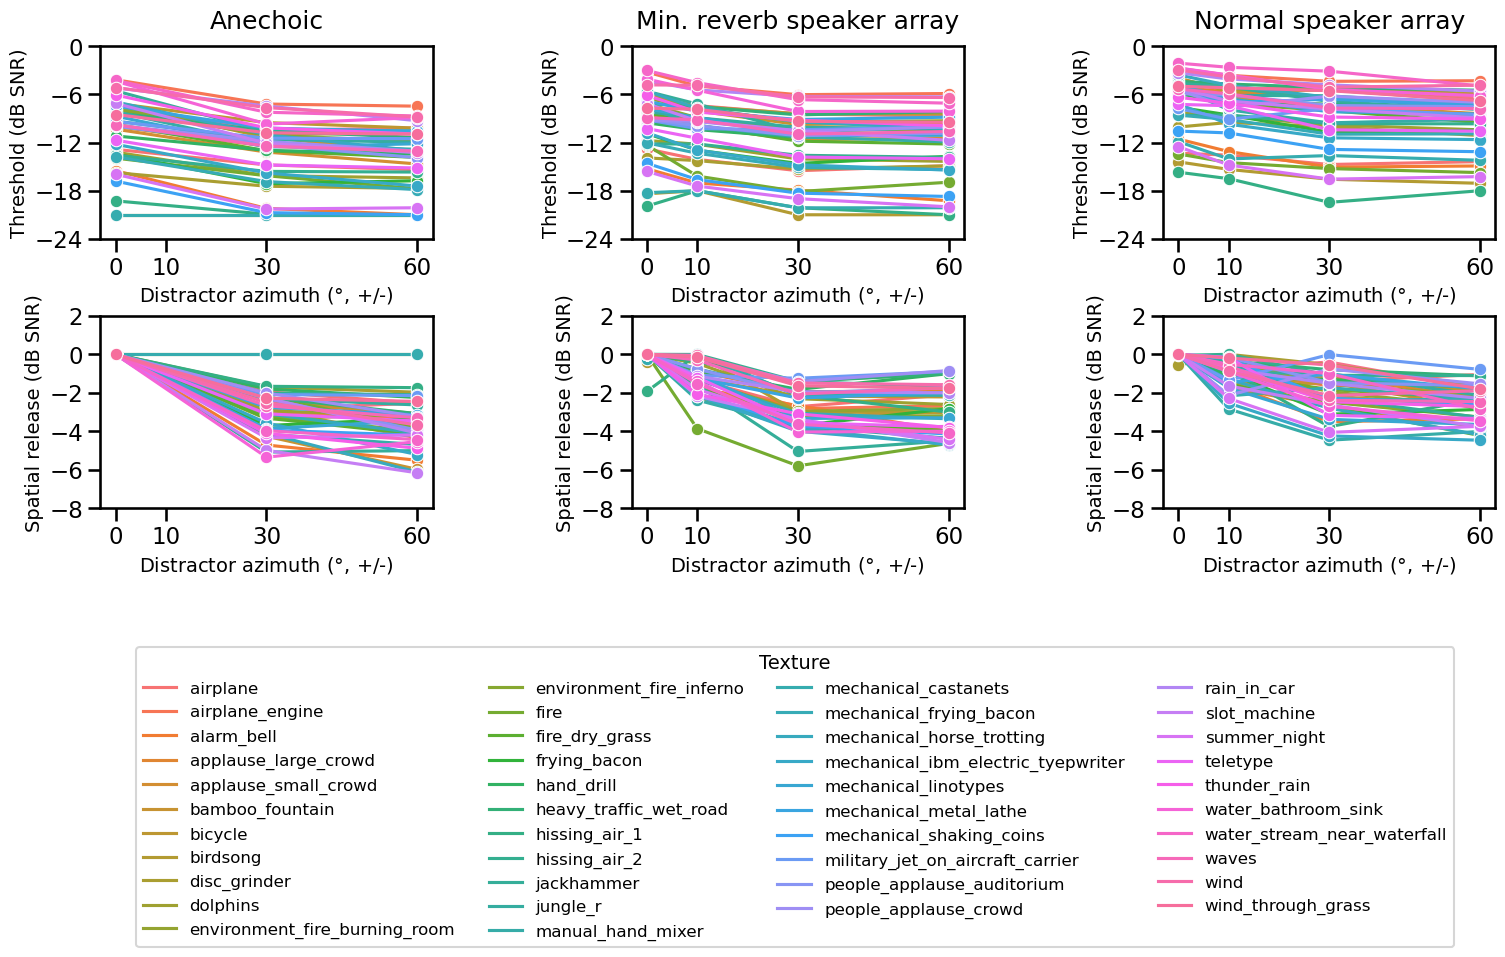

In [66]:


## First, get grand average. Then bootstrap for error 
sns.set_context('talk')


# plt.figure()
# g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
#                 x='snr', y='accuracy_mean', col="distractor_azim",
#                 kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
#                 hue='texture_str', 
#                 row='room_str',
#                 # palette=palette, 
#                 errorbar=('se', 2),
#                 err_style='bars',
#                 height=4, aspect=1)
# g.set_axis_labels("SNR (dB)", "Accuracy")
# # set legend title 
# # new_title = 'Distractor\nazimuth\n($\degree$, +/-)'
# # g._legend.set_title(new_title)
# # set xticks from -9 to 6
# g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# # column titles 
# g.set_titles("{row_name}\n{col_name}")
# plt.suptitle(f'Model azimuth performance', y=1.05)
# # make legend have columns 
# g._legend.remove()
# g.fig.legend( title='Texture', loc='center right', fontsize=8, title_fontsize=8, ncol=4, bbox_to_anchor=(1.1, 0.5))

fontsize=14
# get srm per model
for model in azim_thresh_df.model.unique():
    for dist_type in azim_thresh_df.dist_type.unique():
        for room_type in azim_thresh_df.room.unique():
            ixs = (azim_thresh_df.model == model) & (azim_thresh_df.dist_type == dist_type) & (azim_thresh_df.room == room_type)
            model_data = azim_thresh_df[ixs]
            azim_thresh_df.loc[ixs, 'srm'] = model_data.threshold - model_data.threshold.max()
# plot azim thresholds

# sns.set_style('white')
fig, axs = plt.subplots(2,3, figsize=(18, 6))
for ix, room in enumerate(azim_thresh_df.room.unique()):
    data = azim_thresh_df[azim_thresh_df.room == room]
    sns.lineplot(data=data, x='azim', y='threshold', hue='dist_type', marker='o', ax=axs[0,ix],  legend=False)
    axs[0,ix].set_title(f'{room}', y=1.05)
# axs[0].set_title(f'Model azimuth thresholds', y=1.05)
# axs[0].set_title(f'Model azimuth thresholds', y=1.05)

    axs[0, ix].set_xlabel('Distractor azimuth ($\degree$, +/-)', fontsize=fontsize)
    axs[0, ix].set_ylabel("Threshold (dB SNR)", fontsize=fontsize)
    axs[0, ix ].set_ylim(-24,0)
    axs[0, ix ].set_xticks([0, 10, 30, 60])
    axs[0, ix].set_yticks(np.arange(-24,1,6))


    # sns.set_style('white')
    sns.lineplot(data=data, x='azim', y='srm', hue='dist_type',  marker='o', ax=axs[1, ix], legend=True if ix == 1 else False )
    # axs[1].set_title(f'Model azimuth spatial release', y=1.05)
    axs[1, ix].set_xlabel('Distractor azimuth ($\degree$, +/-)', fontsize=fontsize)
    axs[1, ix].set_ylabel("Spatial release (dB SNR)", fontsize=fontsize)
    axs[1, ix].set_ylim(-8,2)
    axs[1, ix].set_xticks([0, 10, 30, 60])
    axs[1, ix].set_yticks(np.arange(-8,3,2))

# adjust w space 
plt.subplots_adjust(wspace=0.6, hspace=0.4)
# adjust legend 
handles, labels = axs[1,1].get_legend_handles_labels()
axs[1,1].legend(handles=handles[1:], labels=labels[1:], title='Texture',  loc='center right', ncol=4, fontsize=12, title_fontsize=fontsize, bbox_to_anchor=(2.5, -1.5))



In [72]:
# avg threshold estimates for 0 and 10 elevation separation 
to_plot = grouped_model_results[
                    # (grouped_model_results.n_distractors == 2)
                        #   & (grouped_model_results.room_str == 'Min. reverb speaker array')
                        	(grouped_model_results.distractor_azim == 0) 
                        #   & (grouped_model_results.snr.isin([6,3, 0, -3, -6, -9]))
                          ]

to_plot['elev_delta'] = (to_plot['target_elev'] - to_plot['distractor_elev']).abs()

elev_results_for_thresh = to_plot.groupby(['model', 'room_str', 'elev_delta', 'texture_str', 'snr']).agg({'accuracy_mean':'mean'}).reset_index()



elev_thresholds = []
# p0 = [0.0, -4, 4]
for (model, room, dist_type, elev_delta), group in elev_results_for_thresh.groupby(['model', 'room_str', 'texture_str', 'elev_delta']): #, 'gender_cond']):
    thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.accuracy_mean.values, bounds_from_data=True)#, p0=p0)
    if np.isnan(thresh):
        print(f"Threshold is nan for elev {elev_delta}")
    elev_thresholds.append({'model':model, "room":room, "dist_type":dist_type, 'elev_delta': elev_delta, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
elev_thresh_df = pd.DataFrame(elev_thresholds)


/tmp/ipykernel_712194/4137295257.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['elev_delta'] = (to_plot['target_elev'] - to_plot['distractor_elev']).abs()


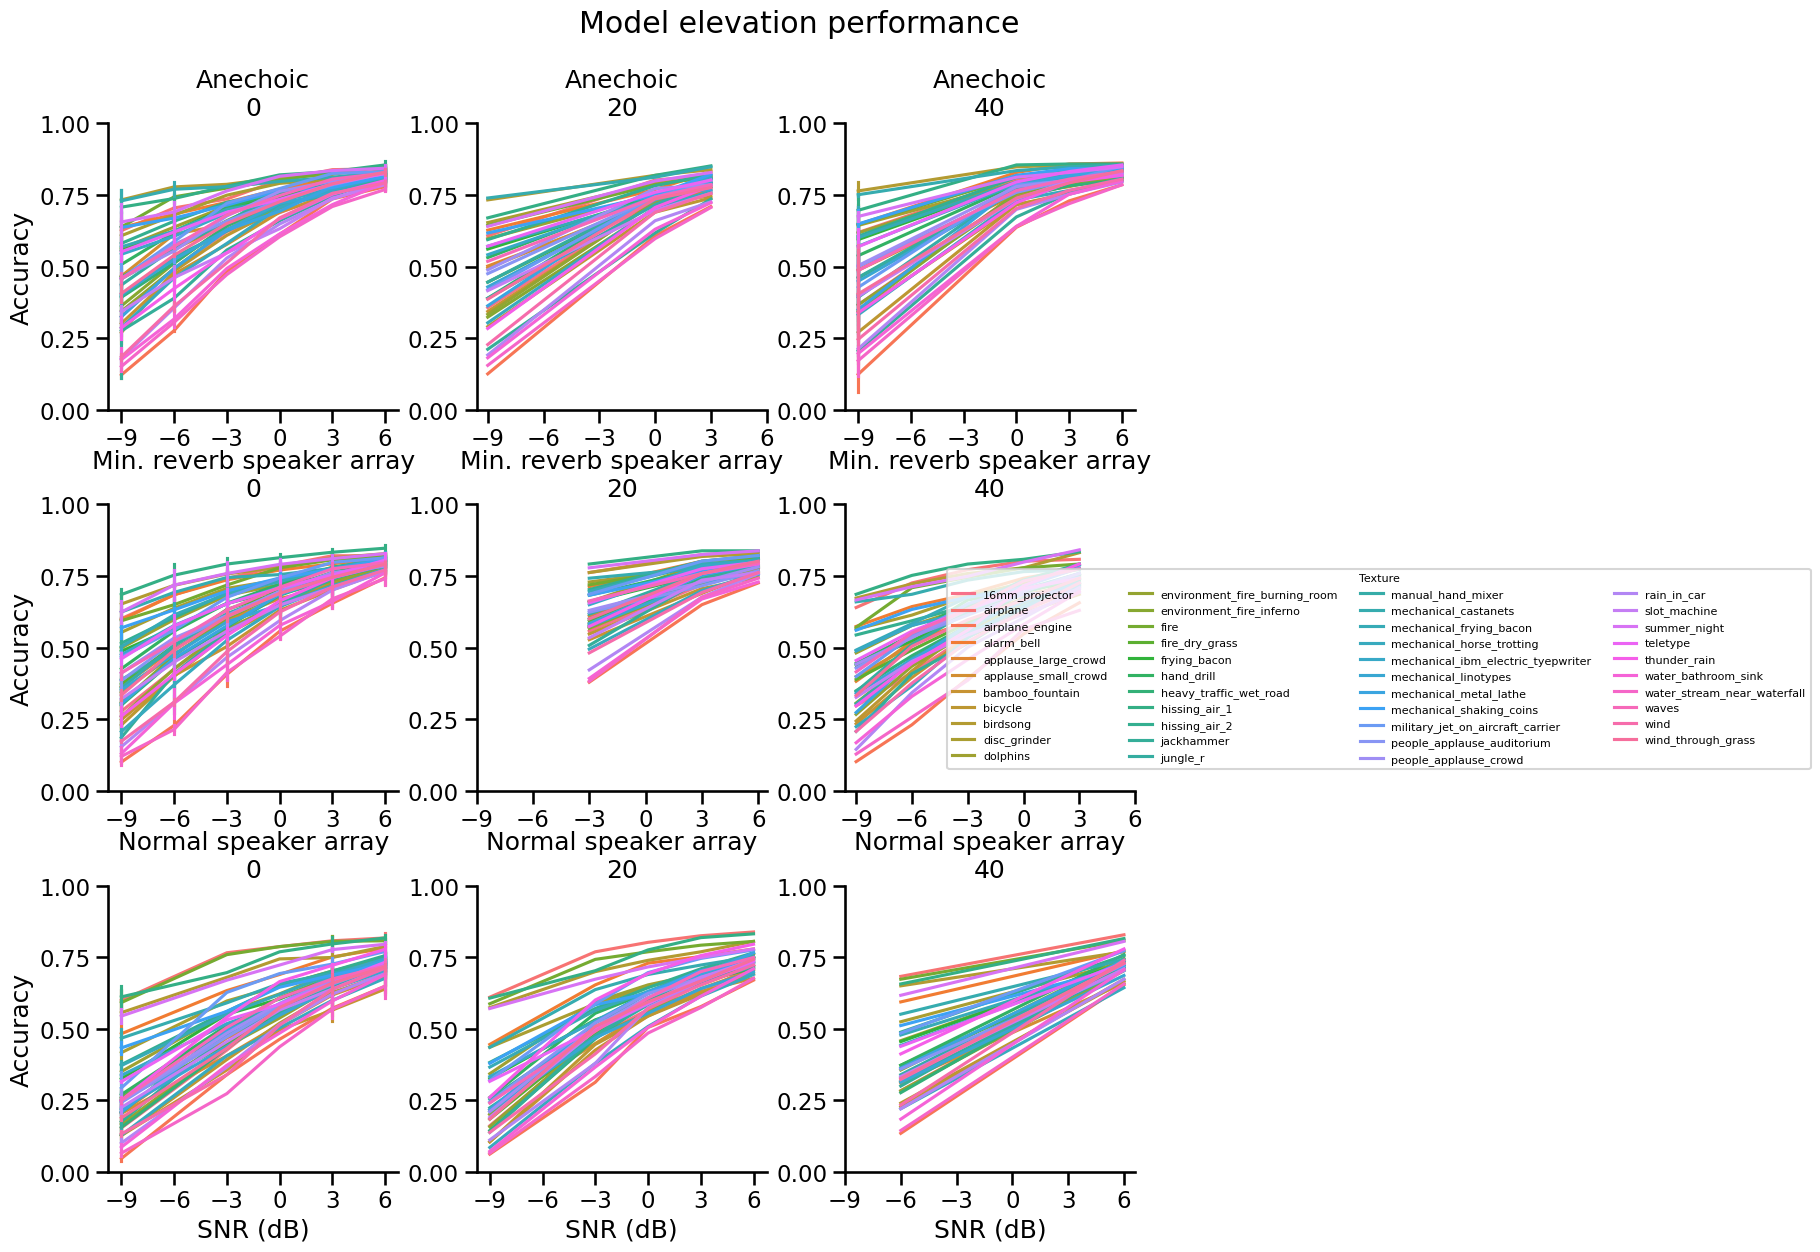

In [75]:
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                x='snr', y='accuracy_mean', col="elev_delta",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                hue='texture_str', 
                row='room_str',
                # palette=palette, 
                errorbar=('se', 2),
                err_style='bars',
                height=4, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
# new_title = 'Distractor\nazimuth\n($\degree$, +/-)'
# g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{row_name}\n{col_name}")
plt.suptitle(f'Model elevation performance', y=1.05)
# make legend have columns 
g._legend.remove()
g.fig.legend( title='Texture', loc='center right', fontsize=8, title_fontsize=8, ncol=4, bbox_to_anchor=(1.1, 0.5))

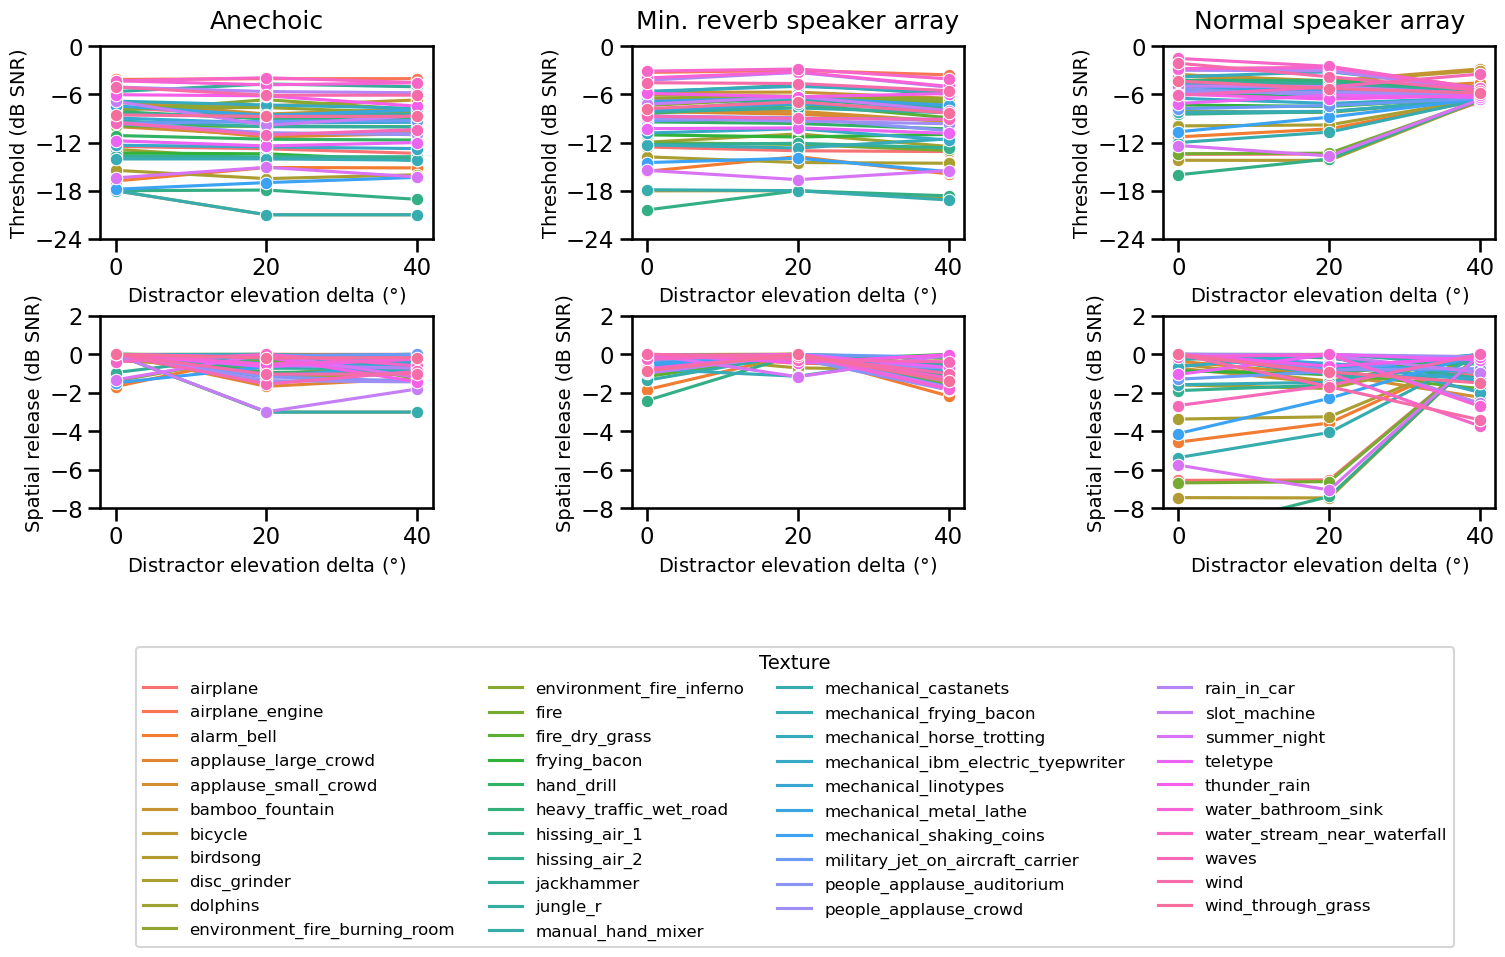

In [74]:


## First, get grand average. Then bootstrap for error 
sns.set_context('talk')


# plt.figure()
# g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
#                 x='snr', y='accuracy_mean', col="distractor_azim",
#                 kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
#                 hue='texture_str', 
#                 row='room_str',
#                 # palette=palette, 
#                 errorbar=('se', 2),
#                 err_style='bars',
#                 height=4, aspect=1)
# g.set_axis_labels("SNR (dB)", "Accuracy")
# # set legend title 
# # new_title = 'Distractor\nazimuth\n($\degree$, +/-)'
# # g._legend.set_title(new_title)
# # set xticks from -9 to 6
# g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# # column titles 
# g.set_titles("{row_name}\n{col_name}")
# plt.suptitle(f'Model azimuth performance', y=1.05)
# # make legend have columns 
# g._legend.remove()
# g.fig.legend( title='Texture', loc='center right', fontsize=8, title_fontsize=8, ncol=4, bbox_to_anchor=(1.1, 0.5))

xticks = [0, 20, 40] 
fontsize=14
# get srm per model
for model in elev_thresh_df.model.unique():
    for dist_type in elev_thresh_df.dist_type.unique():
        for room_type in elev_thresh_df.room.unique():
            ixs = (elev_thresh_df.model == model) & (elev_thresh_df.dist_type == dist_type) & (elev_thresh_df.room == room_type)
            model_data = elev_thresh_df[ixs]
            elev_thresh_df.loc[ixs, 'srm'] = model_data.threshold - model_data.threshold.max()
# plot azim thresholds

# sns.set_style('white')
fig, axs = plt.subplots(2,3, figsize=(18, 6))
for ix, room in enumerate(elev_thresh_df.room.unique()):
    data = elev_thresh_df[elev_thresh_df.room == room]
    sns.lineplot(data=data, x='elev_delta', y='threshold', hue='dist_type', marker='o', ax=axs[0,ix],  legend=False)
    axs[0,ix].set_title(f'{room}', y=1.05)
# axs[0].set_title(f'Model azimuth thresholds', y=1.05)
# axs[0].set_title(f'Model azimuth thresholds', y=1.05)

    axs[0, ix].set_xlabel('Distractor elevation delta ($\degree$)', fontsize=fontsize)
    axs[0, ix].set_ylabel("Threshold (dB SNR)", fontsize=fontsize)
    axs[0, ix ].set_ylim(-24,0)
    axs[0, ix].set_yticks(np.arange(-24,1,6))
    axs[0, ix ].set_xticks(xticks)


    # sns.set_style('white')
    sns.lineplot(data=data, x='elev_delta', y='srm', hue='dist_type',  marker='o', ax=axs[1, ix], legend=True if ix == 1 else False )
    # axs[1].set_title(f'Model azimuth spatial release', y=1.05)
    axs[1, ix].set_xlabel('Distractor elevation delta ($\degree$)', fontsize=fontsize)
    axs[1, ix].set_ylabel("Spatial release (dB SNR)", fontsize=fontsize)
    axs[1, ix].set_ylim(-8,2)
    axs[1, ix].set_yticks(np.arange(-8,3,2))
    axs[1, ix].set_xticks(xticks)


# adjust w space 
plt.subplots_adjust(wspace=0.6, hspace=0.4)
# adjust legend 
handles, labels = axs[1,1].get_legend_handles_labels()
axs[1,1].legend(handles=handles[1:], labels=labels[1:], title='Texture',  loc='center right', ncol=4, fontsize=12, title_fontsize=fontsize, bbox_to_anchor=(2.5, -1.5))



/tmp/ipykernel_706207/1095075754.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['elev_delta'] = (to_plot['target_elev'] - to_plot['distractor_elev']).abs()


<Figure size 640x480 with 0 Axes>

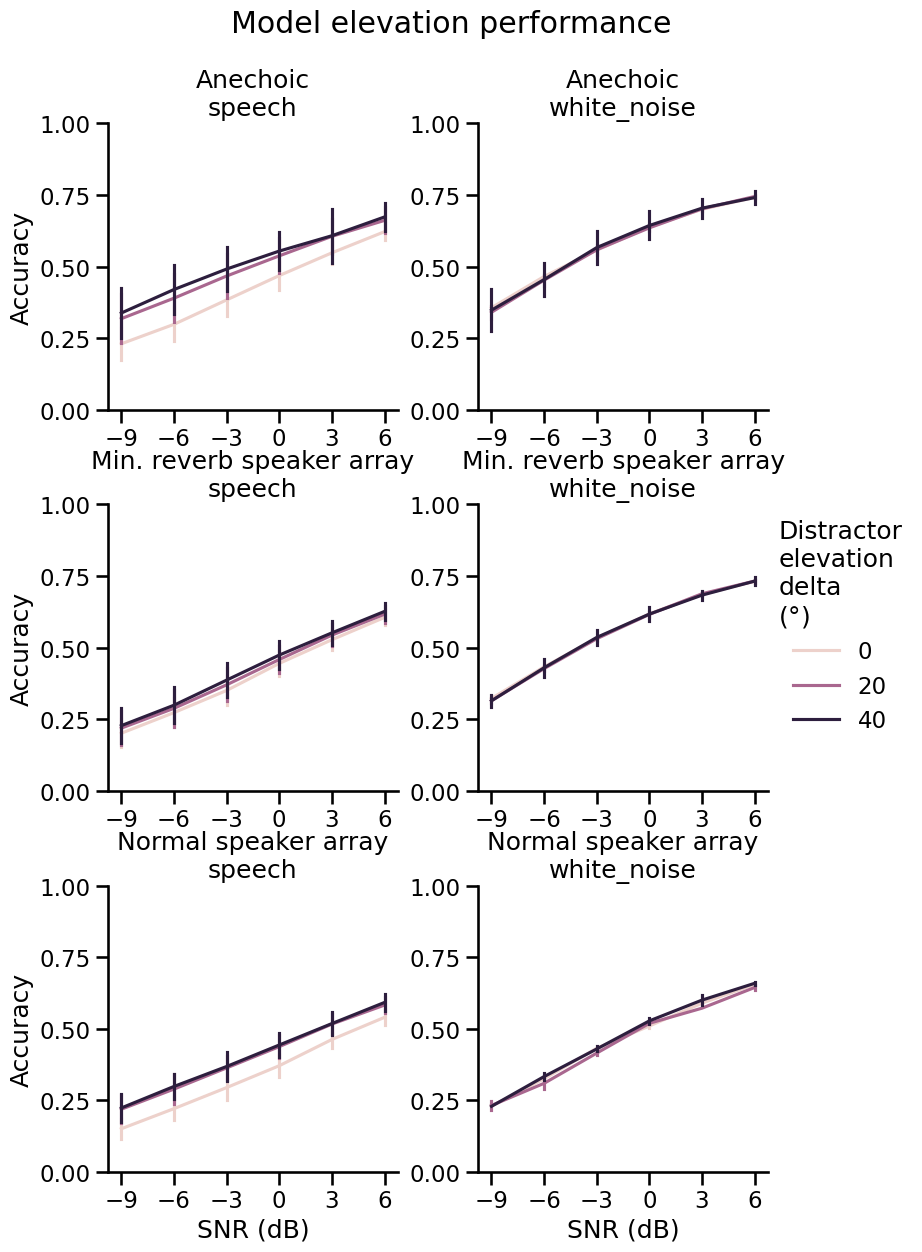

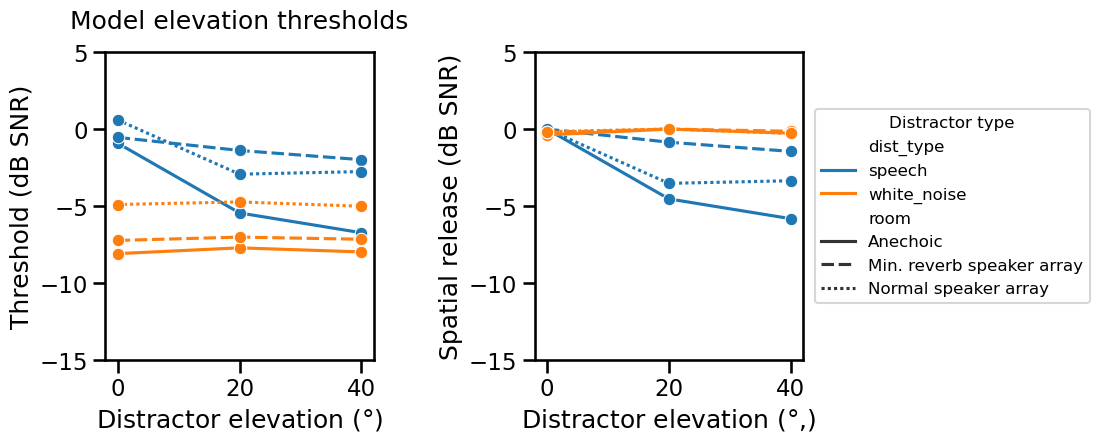

In [ ]:


## First, get grand average. Then bootstrap for error 
sns.set_context('talk')



plt.figure()
g = sns.relplot(data=to_plot[(to_plot.snr.isin([6,3, 0, -3, -6, -9]))],
                x='snr', y='accuracy_mean', hue="elev_delta",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                col='distractor_type', 
                row='room_str',
                # palette=palette, 
                errorbar=('se', 2),
                err_style='bars',
                height=4, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nelevation\ndelta\n($\degree$)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# plt.title(f'Model elevation performance', y=1.05)
g.set_titles("{row_name}\n{col_name}")
plt.suptitle(f'Model elevation performance', y=1.05)

# plot azim thresholds
# sns.set_style('white')
fig, axs = plt.subplots(1,2, figsize=(9, 4))
g = sns.lineplot(data=elev_thresh_df, x='elev_delta', y='threshold',  hue='dist_type', style='room', marker='o', ax=axs[0], legend=False)
axs[0].set_title(f'Model elevation thresholds', y=1.05)
axs[0].set_xlabel('Distractor elevation ($\degree$)')
axs[0].set_ylabel("Threshold (dB SNR)")
axs[0].set_ylim(-15,5)

for model in elev_thresh_df.model.unique():
    for dist_type in elev_thresh_df.dist_type.unique():
        for room_type in elev_thresh_df.room.unique():
            ixs = (elev_thresh_df.model == model) & (elev_thresh_df.dist_type == dist_type) & (elev_thresh_df.room == room_type)
            model_data = elev_thresh_df[ixs]
            elev_thresh_df.loc[ixs, 'srm'] = model_data.threshold - model_data.threshold.max()

# sns.set_style('white')
# plt.figure(figsize=(4, 4))
g = sns.lineplot(data=elev_thresh_df, x='elev_delta', y='srm',  hue='dist_type', style='room', marker='o', ax=axs[1], legend=True)
# plt.title(f'Model elevation spatial release', y=1.05)
axs[1].set_xlabel('Distractor elevation ($\degree$,)')
axs[1].set_ylabel("Spatial release (dB SNR)")
axs[1].set_ylim(-15,5)

# adjust w space 
plt.subplots_adjust(wspace=0.6)
# adjust w space 
plt.subplots_adjust(wspace=0.6)
# adjust legend 
handles, labels = axs[1].get_legend_handles_labels()
axs[1].legend(handles=handles, labels=labels, title='Distractor type', loc='center right', fontsize=12, title_fontsize=12, bbox_to_anchor=(2.1, 0.5))


/tmp/ipykernel_923870/55910426.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot.distractor_azim = to_plot.distractor_azim.abs()


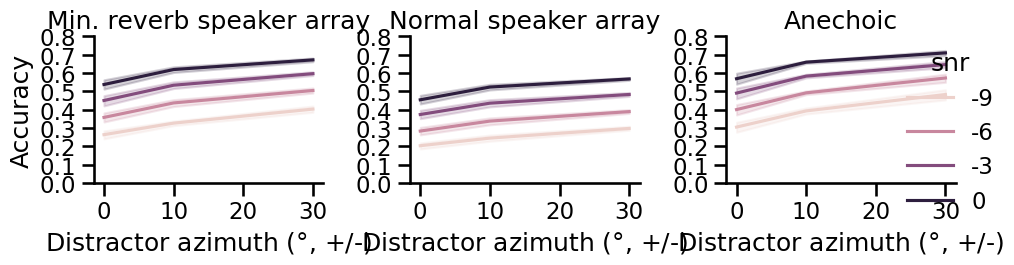

In [ ]:
### Copy human plot above
to_plot = grouped_model_results[
    # (grouped_model_results.n_distractors == 2)
                        #   & (grouped_model_results.room_str == 'Normal speaker array')
                        #   & (grouped_model_results.model == 'word_task_half_co_loc_v07')
                          (grouped_model_results.distractor_azim.isin([0, -10, -30])) 
                          & (grouped_model_results.snr.isin([0, -3, -6, -9]))]

to_plot.distractor_azim = to_plot.distractor_azim.abs()
g = sns.relplot(data=to_plot,
                x='distractor_azim', y='accuracy_mean', hue="snr",
                kind='line', legend='full', 
                facet_kws={"sharey":False, "sharex":False},
                # col='n_distractors', 
                col='room_str',
                # style='test_set',
                # palette=palette, 
                height=3, aspect=1)

# plt.title('Model')
g.set_titles("{col_name}")
g.set(yticks = np.arange(0, 0.81, .1), xticks=np.arange(0, 31, 10))
# plt.ylim(0,0.8)
g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Accuracy")
# set titles 
# g.set_titles("Target elevation: {row_name}\n{col_name}")
plt.tight_layout()

/tmp/ipykernel_586471/3769347842.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot.distractor_azim = to_plot.distractor_azim.abs()


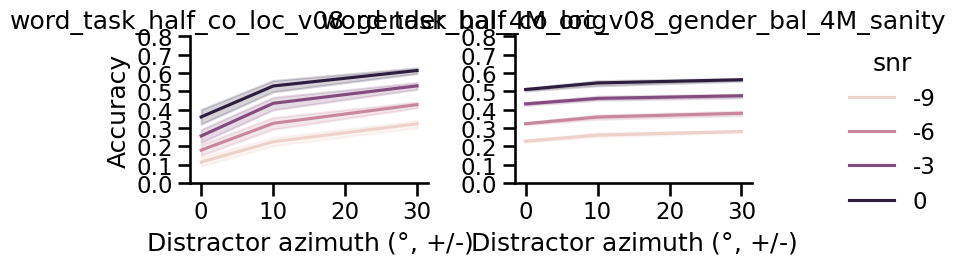

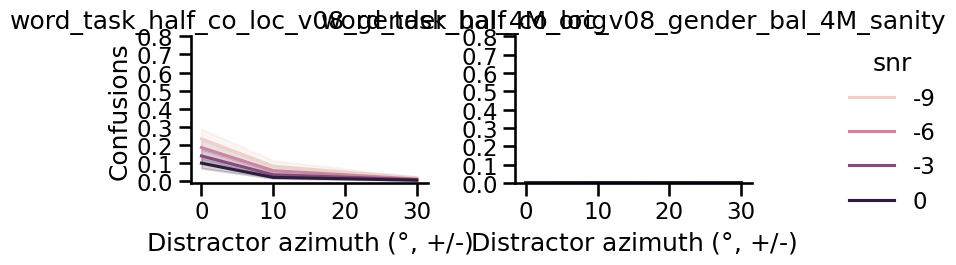

In [ ]:
### Copy human plot above
to_plot = grouped_model_results[(grouped_model_results.n_distractors == 2)
                          & (grouped_model_results.room_str == 'Normal speaker array')
                        #   & (grouped_model_results.model == 'word_task_half_co_loc_v07')
                          & (grouped_model_results.distractor_azim.isin([0, -10, -30])) 
                          & (grouped_model_results.test_set == 'all_stim') 
                          & (grouped_model_results.snr.isin([0, -3, -6, -9]))]

to_plot.distractor_azim = to_plot.distractor_azim.abs()
g = sns.relplot(data=to_plot,
                x='distractor_azim', y='accuracy_mean', hue="snr",
                kind='line', legend='full', 
                facet_kws={"sharey":False, "sharex":False},
                col='model', 
                # palette=palette, 
                height=3, aspect=1)

# plt.title('Model')
g.set_titles("{col_name}")
g.set(yticks = np.arange(0, 0.81, .1), xticks=np.arange(0, 31, 10))
# plt.ylim(0,0.8)
g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Accuracy")
# set titles 
# g.set_titles("Target elevation: {row_name}\n{col_name}")
plt.tight_layout()
g = sns.relplot(data=to_plot,
                x='distractor_azim', y='confusions_mean', hue="snr",
                kind='line', legend='full', 
                facet_kws={"sharey":False, "sharex":False},
                col='model', 
                # palette=palette, 
                height=3, aspect=1)

# plt.title('Model')
g.set_titles("{col_name}")
g.set(yticks = np.arange(0, 0.81, .1), xticks=np.arange(0, 31, 10))
# plt.ylim(0,0.8)
g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Confusions")
# set titles 
# g.set_titles("Target elevation: {row_name}\n{col_name}")
plt.tight_layout()

In [ ]:
grouped_model_results[grouped_model_results.n_distractors == 2].distractor_elev.unique()

array([-20,   0,  20,  40])

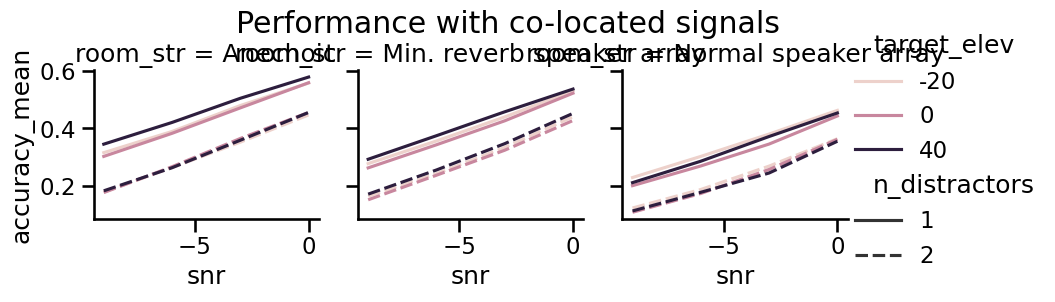

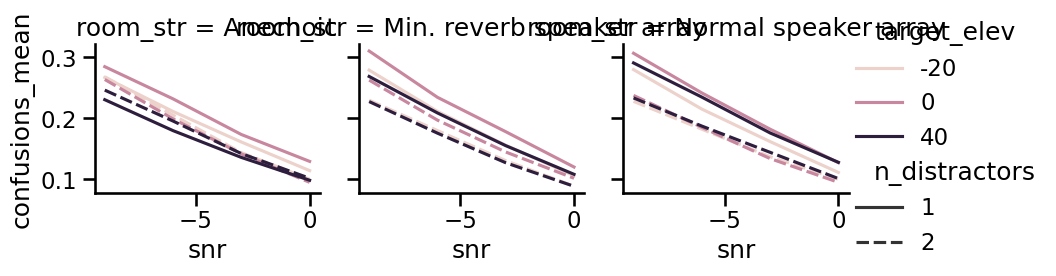

In [ ]:
to_plot =  grouped_model_results[
                          #  (grouped_model_results.room_str == 'Normal speaker array')
                           (grouped_model_results.model == 'word_task_half_co_loc_v08_gender_bal_4M_orig')
                        #   & (grouped_model_results.target_elev.isin([-20, 40])) 
                          & (grouped_model_results.distractor_azim == 0)
                          & (grouped_model_results.snr.isin([0, -3, -6, -9]))
                          & (grouped_model_results.test_set == 'all_stim') 

                          ].groupby(['n_distractors','room_str', 'target_elev', 'snr']).agg({"accuracy_mean":'mean', 'confusions_mean':'mean'}).reset_index()

sns.relplot(data=to_plot, x='snr', y='accuracy_mean', kind='line',
            hue='target_elev',
            style='n_distractors',
            col='room_str',
            height=3, aspect=1)
plt.suptitle('Performance with co-located signals', y=1.02)

sns.relplot(data=to_plot, x='snr', y='confusions_mean', kind='line',
            hue='target_elev',
            style='n_distractors',
            col='room_str',
            height=3, aspect=1)


In [ ]:
to_plot.room_str.unique()

array(['Anechoic', 'Min. reverb speaker array', 'Normal speaker array'],
      dtype=object)

/tmp/ipykernel_3609060/1433606102.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['elev_delta'] = (to_plot['target_elev'] - to_plot['distractor_elev']).abs()


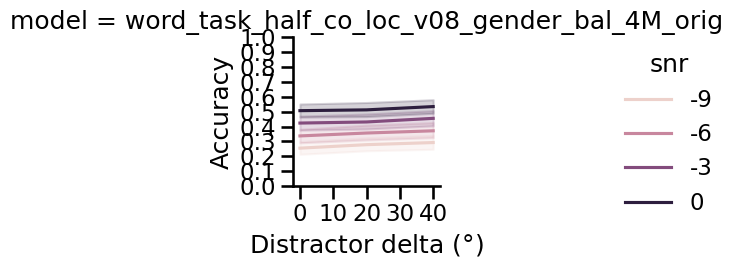

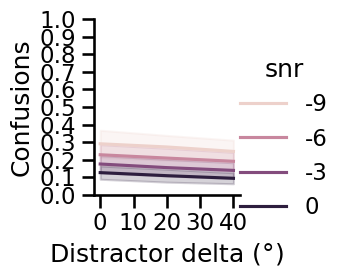

In [ ]:
### Copy human plot above
to_plot = grouped_model_results[
                           (grouped_model_results.n_distractors == 1) 
                        #    (grouped_model_results.room_str == 'Normal speaker array')
                          # & (grouped_model_results.model == 'word_task_half_co_loc_v07')
                          & (grouped_model_results.target_elev.isin([-20, 40])) 
													&	(grouped_model_results.distractor_azim == 0) 

                          & (grouped_model_results.test_set == 'all_stim') 

                          & (grouped_model_results.snr.isin([0, -3, -6, -9]))]


# to_plot = results_df[results_df.n_distractors == 1]
to_plot['elev_delta'] = (to_plot['target_elev'] - to_plot['distractor_elev']).abs()

g = sns.relplot(data=to_plot,
                x='elev_delta', y='accuracy_mean', hue="snr",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                col='model', 
                # row='target_elev',
                # palette=palette, 
                # errorbar=('se', 2),
                height=3, aspect=1)
# plt.title('Humans (N=2)')
g.set(yticks=np.arange(0, 1.1, .1), xticks=np.arange(0, 41, 10))
# plt.ylim(0,0.8)
g.set_axis_labels("Distractor delta ($\degree$)", "Accuracy")
# g.set_titles("{col_name} {row_name}")


g = sns.relplot(data=to_plot,
                x='elev_delta', y='confusions_mean', hue="snr",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                # col='model', 
                # col='target_elev',
                # palette=palette, 
                # errorbar=('se', 2),
                height=3, aspect=1)
# plt.title('Humans (N=2)')
g.set(yticks=np.arange(0, 1.1, .1), xticks=np.arange(0, 41, 10))
# plt.ylim(0,0.8)
g.set_axis_labels("Distractor delta ($\degree$)", "Confusions")
# g.set_titles("{col_name}")


/tmp/ipykernel_3609060/4183547556.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['elev_delta'] = (to_plot['target_elev'] - to_plot['distractor_elev']).abs()


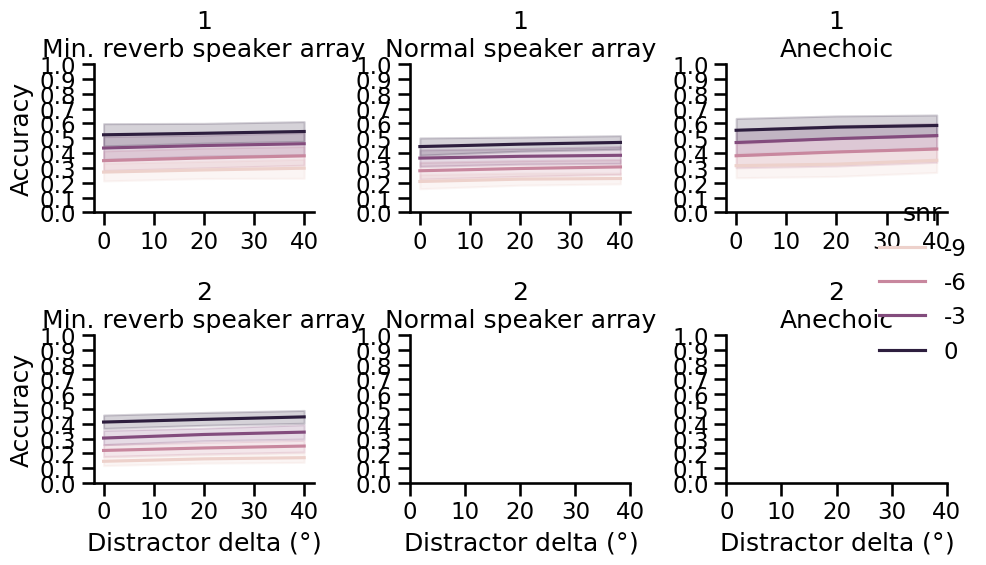

In [ ]:
### Copy human plot above
to_plot = grouped_model_results[
    # (grouped_model_results.n_distractors == 1)
                        #   & (grouped_model_results.room_str == 'Anechoic')
                          # & (grouped_model_results.model == 'word_task_half_co_loc_v07')
                           (grouped_model_results.target_elev.isin([-20, 40])) 
                          & (grouped_model_results.distractor_azim == 0) 
                          & (grouped_model_results.snr.isin([0, -3, -6, -9]))]


# to_plot = results_df[results_df.n_distractors == 1]
to_plot['elev_delta'] = (to_plot['target_elev'] - to_plot['distractor_elev']).abs()

g = sns.relplot(data=to_plot,
                x='elev_delta', y='accuracy_mean', hue="snr",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                # row='model', 
                col='room_str',
                row='n_distractors',
                # palette=palette, 
                # errorbar=('se', 2),
                height=3, aspect=1)
# plt.title('Humans (N=2)')
g.set(yticks=np.arange(0, 1.1, .1), xticks=np.arange(0, 41, 10))
# plt.ylim(0,0.8)
g.set_axis_labels("Distractor delta ($\degree$)", "Accuracy")


# set titles 
g.set_titles("{row_name}\n{col_name}")
# g = sns.relplot(data=to_plot,
#                 x='elev_delta', y='accuracy_mean', hue="snr",
#                 kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
#                 col='target_elev', 
#                 # palette=palette, 
#                 # errorbar=('se', 2),
#                 height=3, aspect=1)
# # plt.title('Humans (N=2)')
# # g.set( xticks=np.arange(0, 31, 10))
# # plt.ylim(0,0.8)
# g.set_axis_labels("Distractor delta ($\degree$)", "Accuracy")
# # set titles 

# move legend up 
plt.tight_layout()


In [ ]:
### Make threshold dataframe 
thresholds = []
for (model, room, target_azim, target_elev, dist_azim, dist_elev, n_dist, dist_type), group in grouped_model_results.groupby(['model', 'room_str', 'target_azim', 'target_elev', 'distractor_azim', 'distractor_elev', 'n_distractors', 'distractor_type']): #, 'gender_cond']):
    try:
        thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.accuracy_mean.values, bounds_from_data=True)
        thresholds.append({'model':model, 'room_ix':room, 'target_azim':target_azim, 'target_elev':target_elev, 
                        'dist_azim':dist_azim, 'dist_elev':dist_elev, 'n_distractors':n_dist, 'dist_type':dist_type, 'threshold':thresh}) #  'gender_cond':gend_cond,
    except Exception as e:
        print(f"Failed to estimate threshold for {model} {room} {target_azim} {target_elev} {dist_azim} {dist_elev} {n_dist} {dist_type}")
        print(e)
        continue
    
thresh_df = pd.DataFrame(thresholds)


Failed to estimate threshold for word_task_half_co_loc_v08_gender_bal_4M_sanity Min. reverb speaker array 0 -20 -180 -20 2 white_noise
Each lower bound must be strictly less than each upper bound.
Failed to estimate threshold for word_task_half_co_loc_v08_gender_bal_4M_sanity Min. reverb speaker array 0 -20 -150 -20 2 white_noise
Each lower bound must be strictly less than each upper bound.
Failed to estimate threshold for word_task_half_co_loc_v08_gender_bal_4M_sanity Min. reverb speaker array 0 -20 -120 -20 2 white_noise
Each lower bound must be strictly less than each upper bound.
Failed to estimate threshold for word_task_half_co_loc_v08_gender_bal_4M_sanity Min. reverb speaker array 0 -20 -90 -20 2 white_noise
Each lower bound must be strictly less than each upper bound.
Failed to estimate threshold for word_task_half_co_loc_v08_gender_bal_4M_sanity Min. reverb speaker array 0 0 -10 0 2 white_noise
Each lower bound must be strictly less than each upper bound.
Failed to estimate th

In [ ]:
thresh_df

,model,room_ix,target_azim,target_elev,dist_azim,dist_elev,n_distractors,dist_type,threshold
0,word_task_half_co_loc_v08_gender_bal_4M_orig,Anechoic,0,-20,-180,-20,2,speech,-2.586560
1,word_task_half_co_loc_v08_gender_bal_4M_orig,Anechoic,0,-20,-150,-20,2,speech,-11.260735
2,word_task_half_co_loc_v08_gender_bal_4M_orig,Anechoic,0,-20,-120,-20,2,speech,-13.023613
3,word_task_half_co_loc_v08_gender_bal_4M_orig,Anechoic,0,-20,-90,-20,2,speech,-12.643681
4,word_task_half_co_loc_v08_gender_bal_4M_orig,Anechoic,0,-20,-60,-20,2,speech,-12.679692
...,...,...,...,...,...,...,...,...,...
179,word_task_half_co_loc_v08_gender_bal_4M_sanity,Min. reverb speaker array,0,40,0,0,2,white_noise,-7.981337
180,word_task_half_co_loc_v08_gender_bal_4M_sanity,Min. reverb speaker array,0,40,0,20,2,speech,-0.056112
181,word_task_half_co_loc_v08_gender_bal_4M_sanity,Min. reverb speaker array,0,40,0,20,2,white_noise,-3.000000
182,word_task_half_co_loc_v08_gender_bal_4M_sanity,Min. reverb speaker array,0,40,0,40,2,speech,1.487506


/tmp/ipykernel_163568/2273895222.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['distractor_azim'] = to_plot.dist_azim.abs()


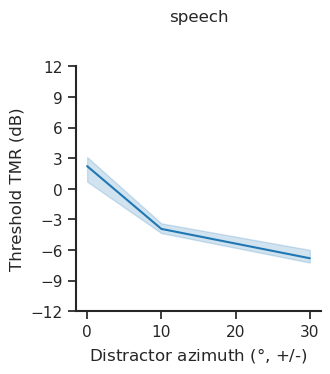

In [ ]:
# plot thresholds for each model 



### Copy human plot above
to_plot = thresh_df[(thresh_df.n_distractors == 2)
                          & (thresh_df.room_ix == 'Normal speaker array')
                          & (thresh_df.model == 'word_task_half_co_loc_v08_gender_bal_4M_orig')
                          & (thresh_df.dist_azim.isin([0, -10, -30])) 
                          ]


to_plot['distractor_azim'] = to_plot.dist_azim.abs()

g = sns.relplot(data=to_plot, x='distractor_azim', y='threshold', kind='line',
                # hue='gender_cond',
                col='dist_type',
                # style='room_ix',
                height=3.5, aspect=1)
# update legend 
g.set_titles("{col_name}", size=12, y=1.15)

g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Threshold TMR (dB)")
g.set(yticks=np.arange(-12,13,3) , xticks=np.arange(0, 31, 10))
ratio = 1 
for ax in g.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)
# g.legend.set_title('')

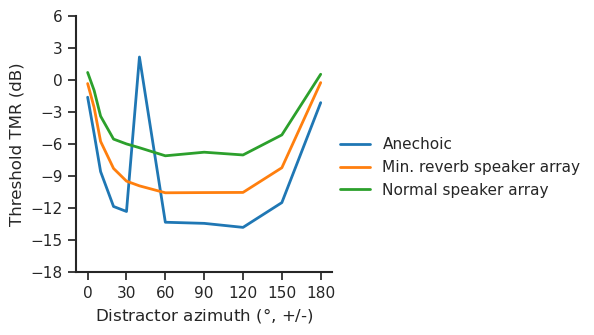

In [ ]:
# plot thresholds for each model 
sns.set_style('ticks')
sns.set_context('notebook', rc={"lines.linewidth": 2})
to_plot = thresh_df[(thresh_df.target_elev == thresh_df.dist_elev)
                    & (thresh_df.model == 'word_task_half_co_loc_v08_gender_bal_4M_orig')
                    # & (thresh_df.room_ix.isin([0,5,9,10]))
                    & (thresh_df.target_elev == 0)
                    & (thresh_df.n_distractors == 2)
                    ].copy()
to_plot['distractor_azim'] = to_plot.dist_azim.abs()
g = sns.relplot(data=to_plot, x='distractor_azim', y='threshold', kind='line',
                # hue='gender_cond',
                # col='model',
                hue='room_ix',
                height=4, aspect=1)
# update legend 
g.set_titles("{col_name}", size=12, y=1.1)

g.set_axis_labels("Distractor azimuth ($\degree$, +/-)", "Threshold TMR (dB)")
g.set(yticks=np.arange(-18,7,3) , xticks=np.arange(0, 181, 30))
ratio = 1 
for ax in g.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)
g.legend.set_title('')

/tmp/ipykernel_163568/874016877.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['dist_elev_delta'] = (to_plot.target_elev - to_plot.dist_elev).abs()


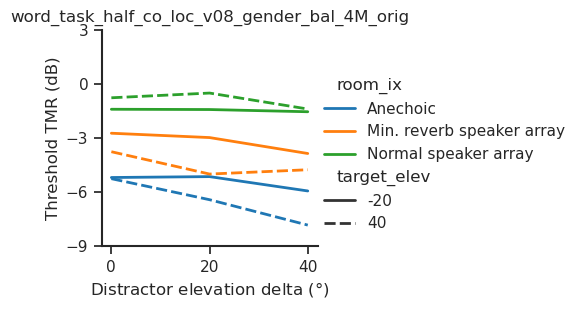

In [ ]:
# plot thresholds for each model 

to_plot = thresh_df[(thresh_df.target_azim == thresh_df.dist_azim)
                    & (thresh_df.model == 'word_task_half_co_loc_v08_gender_bal_4M_orig')
                    & (thresh_df.target_elev.isin([-20, 40]))
                    & (thresh_df.target_azim == 0)
                    & (thresh_df.n_distractors == 1)
                    & (thresh_df.dist_type == 'speech')

                    ]
to_plot['dist_elev_delta'] = (to_plot.target_elev - to_plot.dist_elev).abs()
g = sns.relplot(data=to_plot, x='dist_elev_delta', y='threshold', kind='line',
                # hue='gender_cond',
                col='model',
                style='target_elev',
                hue='room_ix',
                facet_kws={"sharey":False, "sharex":False},
                height=3.5, aspect=1)
# update legend 

g.set_axis_labels("Distractor elevation delta ($\degree$)", "Threshold TMR (dB)")
g.set(yticks=np.arange(-9, 4,3), xticks=np.arange(0, 41, 20))
g.set_titles("{col_name}")

ratio = 1 
for ax in g.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(1.5)
# g.legend.set_title('')
# plt.tight_layout()